# Quickstart Guide


Welcome to `pi-oplsda`! This is a robust Python toolkit for Orthogonal Partial Least Squares Discriminant Analysis (OPLS-DA), specifically designed to achieve seamless alignment with the widely used R package `ropls`.

This tutorial will guide you step-by-step through building a complete analysis pipeline. You will learn how to load data, fit an OPLS-DA model, evaluate its performance via permutation testing, and generate publication-ready diagnostic visualizations. We will use a built-in benchmark metabolomics dataset for a standard binary classification task.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import piopls
from piopls import OPLSDA, OPLSDA_Visualizer
from piopls import load_sacurine

# Print the installed version of pi-oplsda to ensure compatibility
print(f"pi-oplsda version: {piopls.__version__}")

pi-oplsda version: 1.0.0


## 1. Loading the Benchmark Dataset (Sacurine)
The `sacurine` dataset is a classic human urine metabolomics dataset containing 183 samples and 109 metabolite features. 

The target response variable `y` represents the Gender of the individuals (`M` for Male, `F` for Female). This makes our experimental setup a standard **binary classification (two-group) design**, which is the most common usecase for OPLS-DA in biomarker discovery.

In [2]:
# Load the built-in demo dataset.
# The function load_sacurine() returns four variables:
# 1. X: The feature matrix (samples x metabolites)
# 2. y: The target array (class labels for each sample)
# 3. feature_names: The names or IDs of the 109 metabolites
# 4. sample_names: The unique identifiers for the 183 samples
X, y, feature_names, sample_names = load_sacurine()

# Verify the dimensions of our loaded data
print(f"Feature matrix X shape: {X.shape}")
print(f"Target array y shape: {y.shape}")
print(f"Unique classes in y: {np.unique(y)}")

Feature matrix X shape: (183, 109)
Target array y shape: (183,)
Unique classes in y: ['F' 'M']


## 2. Binary Design: OPLS-DA Analysis
For two-group comparisons in metabolomics, **OPLS-DA** is considered the gold standard algorithm. 

Unlike standard PCA or PLS-DA, OPLS-DA effectively filters out orthogonal noise—which is the variation in the dataset that is completely unrelated to the group labels (e.g., technical batch effects or intra-group individual differences). By pushing this noise to orthogonal components, the predictive component becomes much cleaner, allowing for a more precise and interpretable identification of differential metabolites (biomarkers).

### 2.1 Perform OPLS-DA modeling and permutation testing
Here, we instantiate the `OPLSDA` model. A crucial parameter is `n_ortho` (the number of orthogonal components). 
By setting `n_ortho=None`, we instruct the model to automatically determine the optimal number of orthogonal components using Q2 heuristics via cross-validation.

After fitting the model, we perform a multi-core **Permutation Test** to statistically validate that our model is robust and not over-fitted.

In [3]:
# 1. Load DataFrame
# (In this specific example, we load directly from CSV files to demonstrate working with pandas DataFrames)
df_X = pd.read_csv("../src/piopls/data/sacurine_X.csv", index_col=[0])
df_Y = pd.read_csv("../src/piopls/data/sacurine_Y.csv", index_col=[0])
y_data = df_Y.iloc[:, 0].values 

# 2. Model configuration and computation
# cv_folds: Number of folds for cross-validation
# max_ortho: The maximum number of orthogonal components to search if n_ortho is None
# n_perms: Number of permutations for the validation test
# n_jobs: -1 uses all available CPU cores for parallel permutation testing
model_opls = OPLSDA(
    cv_folds=7,
    max_ortho=10, 
    n_perms=100, 
    n_jobs=-1,
    vip_method='vip4'
)

# Fit the OPLS-DA model to the data, with cross-validation and permutation test
perm_results = model_opls.fit_pipeline(df_X, y_data)

# 3. Initialize the Visualizer
# The Visualizer consumes the fitted model and true labels to prepare the plotting environment.
# vip_threshold: The cutoff for highlighting important features in the S-Plot
# top_n_vip: The number of top features to display in the VIP bar plot
vis_opls = OPLSDA_Visualizer(
    model=model_opls, 
    y=y_data, 
    feature_names=None, 
    sample_names=None, 
    vip_threshold=1.2, 
    top_n_vip=27, 
    custom_palette=None
)

Starting parallel permutation test (100 permutations)...


Permutation Test: 100%|███████████████| 100/100 [ETA: 00:00]


### 2.2 Exporting Model Metrics as DataFrames
`pi-oplsda` provides a suite of methods strictly aligned with the `ropls` package to export key parameters as formatted `pandas.DataFrame` objects.

These tables are highly valuable for clinical research reports, allowing users to extract the global summary, component-wise variance explanation, sample scores, and feature selection metrics (e.g., VIP scores, Covariance, Correlation).

In [4]:
# Get a global overview of the model metadata (Matches ropls getSummaryDF)
# Displays N_Predictive, N_Ortho, cumulative R2X/R2Y/Q2, RMSEE, and permutation p-values
display(model_opls.get_model_info_df())

# Get the step-wise summary dataframe showing incremental variance explained by each component (p1, o1, o2...)
display(model_opls.get_summary_df())

# Get the model scores dataframe for samples
# Providing y_true enables the generation of the 'Match_Status' column to flag misclassifications
display(model_opls.get_scores_df(y_true=y_data))

# Get the feature selection dataframe
# Contains VIP scores, Covariance (p1), and Correlation (pcorr1), sorted by VIP in descending order
display(model_opls.get_features_df())

# Get the observation diagnostics dataframe for outlier detection
# Contains Score Distance (SD) and Orthogonal Distance (OD) to evaluate sample deviations
display(model_opls.get_outlier_df())

,N_Predictive,N_Ortho,R2X(cum),R2Y(cum),Q2(cum),RMSEE,pR2Y,pQ2
0,1,2,0.275229,0.729833,0.592026,0.258764,0.009901,0.009901


,Component,R2X,R2Y,Q2,R2X(cum),R2Y(cum),Q2(cum)
0,Predictive (p1),0.049934,0.479107,0.401144,0.049934,0.479107,0.401144
1,Orthogonal (o1),0.125893,0.189217,0.146085,0.175827,0.189217,0.146085
2,Orthogonal (o2),0.099402,0.061509,0.044796,0.275229,0.250726,0.190881


,Sample,t_pred (p1),t_ortho (o1),t_ortho (o2),True_Class,Fitted_Value,Fitted_Class,Match_Status
0,HU_011,1.582933,4.980604,-5.268184,M,0.841541,M,Matched
1,HU_014,-1.372806,1.744338,-0.892428,F,0.290528,F,Matched
2,HU_015,3.341370,3.437277,-2.477440,M,1.169351,M,Matched
3,HU_017,3.590063,0.979496,-3.557066,M,1.215713,M,Matched
4,HU_018,1.662716,-0.315585,3.628218,M,0.856414,M,Matched
...,...,...,...,...,...,...,...,...
178,HU_205,3.020039,0.185278,2.136284,M,1.109448,M,Matched
179,HU_206,-0.238014,-1.022405,3.789028,F,0.502077,M,Mismatched
180,HU_207,-4.860766,-3.253181,0.538034,F,-0.359703,F,Matched
181,HU_208,-1.095204,-5.730609,-0.108418,F,0.342278,F,Matched


,Feature,VIP,Covariance (p1),Correlation (pcorr1),Loading_Weight
0,p-Anisic acid,2.533220,-1.393154,-0.566073,-0.247445
1,Malic acid,2.479289,-0.320155,-0.554021,-0.242177
2,Testosterone glucuronide,2.421591,0.720792,0.541128,0.236541
3,Pantothenic acid,2.165296,-0.282849,-0.483856,-0.211506
4,Acetylphenylalanine,1.988311,-0.359541,-0.444307,-0.194218
...,...,...,...,...,...
104,N-Acetylleucine,0.064791,-0.020148,-0.014478,-0.006329
105,Sebacic acid,0.048940,0.006186,0.010936,0.004781
106,"1,7-Dimethyluric acid",0.032924,0.007197,0.007357,0.003216
107,Deoxyhexose,0.028552,-0.005538,-0.006380,-0.002789


,Sample,Score_Distance,Orthogonal_Distance,Exceeds_SD_Limit,Exceeds_OD_Limit
0,HU_011,2.541852,9.712544,False,False
1,HU_014,0.878093,8.071412,False,False
2,HU_015,2.026329,6.833680,False,False
3,HU_017,2.031636,8.171866,False,False
4,HU_018,1.472447,9.321900,False,False
...,...,...,...,...,...
178,HU_205,1.520278,6.688254,False,False
179,HU_206,1.376736,10.061757,False,False
180,HU_207,2.374211,7.108748,False,False
181,HU_208,1.897843,7.990270,False,False


### 2.3 Visualization

#### 2.3.1 Global Diagnostic Dashboard

With a single line of code, we can generate all five standard publication-ready diagnostic plots combined in a single figure:

1. **Model Overview**: Displays the sequential R2X, R2Y, and Q2 metrics.
2. **Score Plot**: Shows class separation based on predictive/orthogonal scores.
3. **Permutation Test**: Validates model robustness against overfitting.
4. **Observation Diagnostics**: Identifies leverage and orthogonal outliers.
5. **VIP Bar Plot**: Highlights top features contributing to the classification.

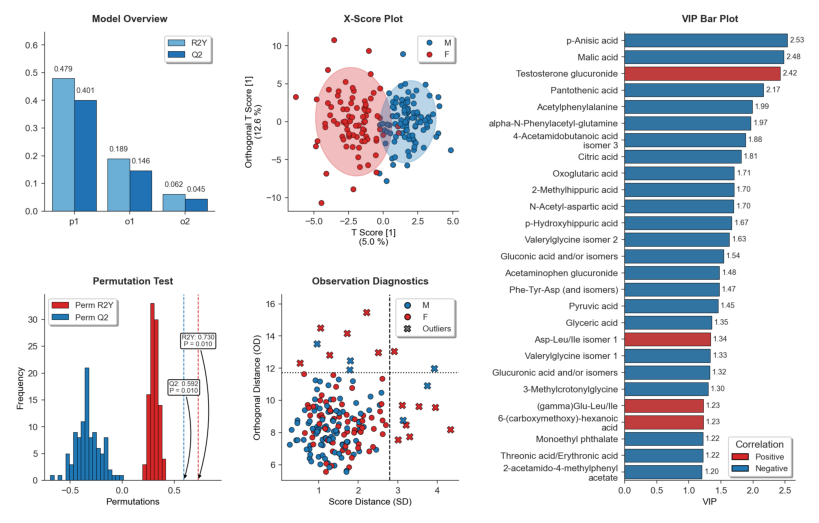

In [5]:
# Generate and display all diagnostic plots in a unified grid layout.
# Pass 'perm_results' to enable the permutation test subplot.
# 'wrap_width' automatically handles long metabolite names in the VIP plot.
# 'figsize' can be customized to fit specific journal column widths.
# Note: The inline display DPI is entirely independent of the 'save_path' 
# export, which strictly maintains publication-grade resolution (300 DPI).
# 'return_fig' and 'show_plot' control the interactive rendering behavior:
#   - return_fig=False, show_plot=True: Displays a standard, low-DPI inline 
#     image rendered via the default Matplotlib backend.
#   - return_fig=True, show_plot=False: Returns the layout object. You must 
#     uncomment the 'vis_summary' line below to display the high-DPI image.

vis_summary = vis_opls.plot_all(
    perm_results=perm_results, 
    wrap_width=30,
    figsize=(8, 6),
    return_fig=False,
    show_plot=True,
    save_path=None
)
# vis_summary

#### 2.3.2 S-Plot Visualization (Optional)
This module fully supports the generation of an S-Plot for feature selection. However, because its core functionality significantly overlaps with the VIP Bar Plot—which offers a more intuitive ranking of variables alongside their correlation directions—the S-Plot is intentionally omitted from the global `plot_all` dashboard to maximize spatial efficiency.

If you prefer the traditional S-Plot perspective to evaluate the covariance and correlation of features simultaneously, you can easily generate it as a standalone figure.

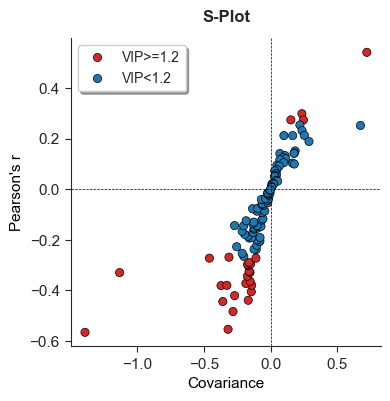

In [6]:
# Initialize a standalone figure for the S-Plot
fig_splot, ax_splot = plt.subplots(figsize=(4, 4))

# Generate the S-Plot using the visualizer instance
# Features exceeding the VIP threshold are highlighted in red
vis_opls.plot_splot(ax=ax_splot)

# Display the plot
plt.show()

### 2.4 Advanced: Plotting and Customizing Individual Subplots
Sometimes, you may want to extract a single plot (e.g., the VIP Bar Plot or the Score Plot) for a specific main figure in your manuscript, and apply highly localized stylistic changes without affecting the global default theme.

Because `pi-oplsda` is built purely on an Object-Oriented Matplotlib architecture, you can pass a specific `ax` (axes object) to any plotting function and manually override its properties.

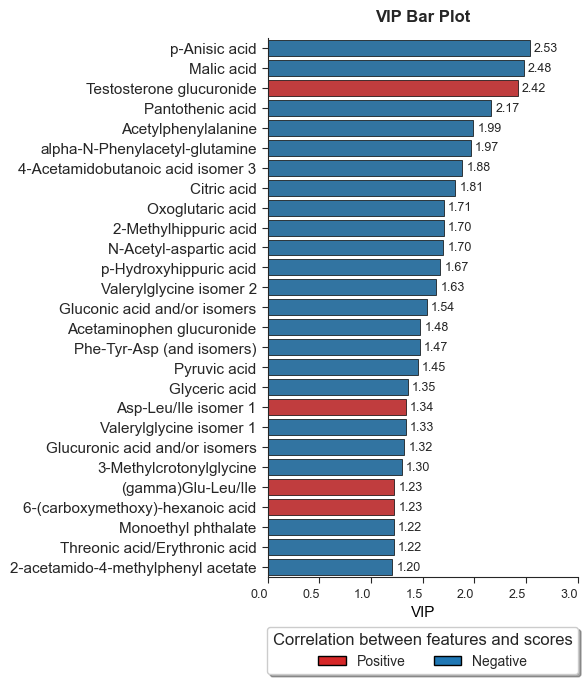

In [7]:
# 1. Create a standalone figure with a specific tall aspect ratio
fig_vip, ax_vip = plt.subplots(figsize=(4, 7))

# 2. Plot ONLY the VIP bar chart on this axis
vis_opls.plot_vip_bar(ax=ax_vip, wrap_width=40)

# 3. Advanced Customization: Extract the default legend and move it outside
old_legend = ax_vip.get_legend()
if old_legend is not None:
    handles = old_legend.legend_handles
    labels = [text.get_text() for text in old_legend.get_texts()]
    title = old_legend.get_title().get_text()
    
    # Re-draw the legend, forcing it to be a 2-column horizontal layout 
    # anchored at the bottom-center, outside the main plotting area.
    ax_vip.legend(
        handles=handles,
        labels=labels,
        title="Correlation between features and scores",
        loc='upper center',
        # X=0.5 (center), Y=-0.08 (below bottom edge)
        bbox_to_anchor=(0.5, -0.08),
        ncol=2,
        frameon=True, 
        shadow=True, 
        fontsize=10, 
        facecolor="white"
    )

ax_vip.set_xticks(
    ticks=ax_vip.get_xticks(), labels=ax_vip.get_xticklabels(),
    rotation=0, ha='right', rotation_mode='anchor', fontsize=9)

plt.show()


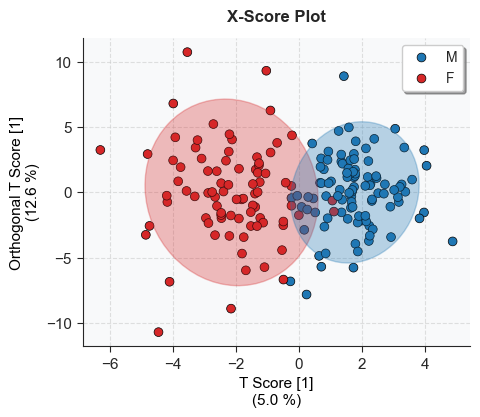

In [8]:
# =====================================================================
# Example B: Standalone Score Plot with local style modifications
# =====================================================================

fig_score, ax_score = plt.subplots(figsize=(5, 4))

# Plot ONLY the Score Scatter plot
vis_opls.plot_score(ax=ax_score)

# Local Override 1: Add grid lines (which are absent by default)
ax_score.grid(True, linestyle='--', alpha=0.6, zorder=0)

# Local Override 2: Add a subtle background color specifically for this plot
ax_score.set_facecolor('#f8f9fa')

plt.show()

### 2.5. Model Prediction and Validation

To evaluate the predictive performance of the model on unseen data, we align 
with the standard `ropls` validation approach. We partition the dataset by 
assigning the odd-indexed samples to the training set and the remaining 
even-indexed samples to the testing set.

In [9]:
# Split the dataset into training (odd samples) and testing (even samples).
# Note: 'odd' samples map to indices 0, 2, 4... in python location coding.
X_train = X[0::2].copy()
y_train = y_data[0::2].copy()

X_test = X[1::2].copy()
y_test = y_data[1::2].copy()

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 92 samples
Testing set size: 91 samples


In [10]:
X_train.shape

(92, 109)

Next, we initialize and fit a new OPLS-DA model exclusively on the training 
set and review its summary parameters.

In [11]:
# Initialize and fit the predictive model on the training subset
model_predict = OPLSDA(
    cv_folds=7,
    max_ortho=10, 
    n_perms=100, 
    n_jobs=-1,
    vip_method='vip4')

# Fit the OPLS-DA model to the data, with cross-validation and permutation test
train_perm_results = model_predict.fit_pipeline(X_train, y_train)

# Display the training model metadata
display(model_predict.get_model_info_df())

Starting parallel permutation test (100 permutations)...


Permutation Test: 100%|███████████████| 100/100 [ETA: 00:00]


,N_Predictive,N_Ortho,R2X(cum),R2Y(cum),Q2(cum),RMSEE,pR2Y,pQ2
0,1,2,0.291779,0.788474,0.565261,0.22947,0.009901,0.009901


Finally, we apply the trained model to predict the classes of both the 
training and testing sets. The classification accuracy is evaluated using 
confusion matrices.

In [12]:
# Generate class predictions for both datasets
y_pred_train = model_predict.predict(X_train)
y_pred_test = model_predict.predict(X_test)

# Compute confusion matrices using pandas crosstab
cm_train = pd.crosstab(
    pd.Series(y_train, name='Actual'), 
    pd.Series(y_pred_train, name='Predicted')
)

cm_test = pd.crosstab(
    pd.Series(y_test, name='Actual'), 
    pd.Series(y_pred_test, name='Predicted')
)

print("=== Training Set Confusion Matrix ===")
display(cm_train)

print("\n=== Testing Set Confusion Matrix ===")
display(cm_test)

=== Training Set Confusion Matrix ===


Predicted,F,M
Actual,,
F,43,0
M,0,49



=== Testing Set Confusion Matrix ===


Predicted,F,M
Actual,,
F,32,8
M,3,48
